# Analiza i testowanie modelu temp_model.h5

Ten notebook analizuje strukturę modelu i testuje go na zdjęciach.

In [10]:
# Importy
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

# Próba załadowania różnych bibliotek do modeli
try:
    import tensorflow as tf
    from tensorflow import keras
    print(f"✅ TensorFlow {tf.__version__} załadowany")
    TF_AVAILABLE = True
except ImportError:
    print("⚠️  TensorFlow nie jest dostępny")
    TF_AVAILABLE = False

try:
    import h5py
    print(f"✅ h5py {h5py.__version__} załadowany")
    H5PY_AVAILABLE = True
except ImportError:
    print("⚠️  h5py nie jest dostępny")
    H5PY_AVAILABLE = False

try:
    from PIL import Image
    print(f"✅ PIL załadowany")
    PIL_AVAILABLE = True
except ImportError:
    print("⚠️  PIL nie jest dostępny")
    PIL_AVAILABLE = False

✅ TensorFlow 2.20.0 załadowany
✅ h5py 3.15.1 załadowany
✅ PIL załadowany


In [11]:
# Sprawdź informacje o pliku modelu
model_path = "temp_model.h5"

if not os.path.exists(model_path):
    print(f"❌ Plik {model_path} nie istnieje!")
else:
    file_size = os.path.getsize(model_path) / (1024 * 1024)  # MB
    print(f"📁 Plik: {model_path}")
    print(f"📦 Rozmiar: {file_size:.2f} MB")
    
    # Sprawdź strukturę pliku HDF5
    if H5PY_AVAILABLE:
        try:
            with h5py.File(model_path, 'r') as f:
                print(f"\n📋 Struktura pliku HDF5:")
                print(f"   Klucze główne: {list(f.keys())}")
                
                def print_structure(name, obj):
                    if isinstance(obj, h5py.Group):
                        print(f"   📁 {name}/ (grupa)")
                    elif isinstance(obj, h5py.Dataset):
                        print(f"   📄 {name}: shape={obj.shape}, dtype={obj.dtype}")
                
                f.visititems(print_structure)
        except Exception as e:
            print(f"⚠️  Nie można odczytać struktury HDF5: {e}")

📁 Plik: temp_model.h5
📦 Rozmiar: 7.84 MB

📋 Struktura pliku HDF5:
   Klucze główne: ['model_weights', 'optimizer_weights']
   📁 model_weights/ (grupa)
   📁 model_weights/concatenate_1/ (grupa)
   📁 model_weights/concatenate_2/ (grupa)
   📁 model_weights/concatenate_3/ (grupa)
   📁 model_weights/concatenate_4/ (grupa)
   📁 model_weights/conv2d_1/ (grupa)
   📁 model_weights/conv2d_1/conv2d_1/ (grupa)
   📄 model_weights/conv2d_1/conv2d_1/bias:0: shape=(16,), dtype=float32
   📄 model_weights/conv2d_1/conv2d_1/kernel:0: shape=(4, 4, 3, 16), dtype=float32
   📁 model_weights/conv2d_10/ (grupa)
   📁 model_weights/conv2d_10/conv2d_10/ (grupa)
   📄 model_weights/conv2d_10/conv2d_10/bias:0: shape=(81,), dtype=float32
   📄 model_weights/conv2d_10/conv2d_10/kernel:0: shape=(4, 4, 81, 81), dtype=float32
   📁 model_weights/conv2d_11/ (grupa)
   📁 model_weights/conv2d_11/conv2d_11/ (grupa)
   📄 model_weights/conv2d_11/conv2d_11/bias:0: shape=(54,), dtype=float32
   📄 model_weights/conv2d_11/conv2d_11/

In [12]:
# Próba załadowania modelu jako Keras/TensorFlow
model = None
model_type = None

if TF_AVAILABLE:
    try:
        print("🔄 Próba załadowania jako model Keras...")
        model = keras.models.load_model(model_path)
        model_type = "keras"
        print("✅ Model załadowany jako Keras/TensorFlow!")
    except Exception as e:
        print(f"⚠️  Nie można załadować jako Keras: {e}")
        print("   (Może to być plik z wagami, nie pełnym modelem)")
else:
    print("⚠️  TensorFlow nie jest dostępny, nie można załadować modelu Keras")

if model is None:
    print("\n❌ Nie udało się załadować modelu. Sprawdź czy to model Keras/TensorFlow.")

🔄 Próba załadowania jako model Keras...


✅ Model załadowany jako Keras/TensorFlow!


In [13]:
# Analiza struktury modelu (jeśli został załadowany)
if model is not None and model_type == "keras":
    print("=" * 60)
    print("📊 ANALIZA MODELU")
    print("=" * 60)
    
    # Podsumowanie modelu
    print("\n📋 Podsumowanie modelu:")
    model.summary()
    
    # Informacje o input/output
    print("\n🔍 Informacje o wejściu/wyjściu:")
    print(f"   Input shape: {model.input_shape}")
    print(f"   Output shape: {model.output_shape}")
    
    # Liczba parametrów
    total_params = model.count_params()
    trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    non_trainable_params = total_params - trainable_params
    
    print(f"\n📊 Parametry modelu:")
    print(f"   Całkowita liczba parametrów: {total_params:,}")
    print(f"   Parametry trenowalne: {trainable_params:,}")
    print(f"   Parametry nietrenowalne: {non_trainable_params:,}")
    
    # Warstwy
    print(f"\n🏗️  Liczba warstw: {len(model.layers)}")
    print("\n📝 Typy warstw:")
    layer_types = {}
    for layer in model.layers:
        layer_type = type(layer).__name__
        layer_types[layer_type] = layer_types.get(layer_type, 0) + 1
    
    for layer_type, count in sorted(layer_types.items()):
        print(f"   {layer_type}: {count}")
    
    # Sprawdź czy to model klasyfikacji czy detekcji
    output_shape = model.output_shape
    if len(output_shape) == 2:
        print(f"\n🎯 Typ modelu: Prawdopodobnie klasyfikacja (output: {output_shape})")
        if output_shape[1] == 1:
            print("   → Klasyfikacja binarna")
        else:
            print(f"   → Klasyfikacja wieloklasowa ({output_shape[1]} klas)")
    elif len(output_shape) == 4:
        print(f"\n🎯 Typ modelu: Prawdopodobnie detekcja obiektów (output: {output_shape})")
    else:
        print(f"\n🎯 Typ modelu: Inny (output: {output_shape})")
    
    print("\n" + "=" * 60)
else:
    print("⚠️  Model nie został załadowany, pomijam analizę")

📊 ANALIZA MODELU

📋 Podsumowanie modelu:


Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_1             │ (None, 480, 720,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 480, 720,  │        784 │ input_1[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 480, 720,  │      4,112 │ conv2d_1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 240, 360,  │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 240, 360,  │      6,168 │ max_pooling2d_1[… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 240, 360,  │      9,240 │ conv2d_3[0][0]    │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 120, 180,  │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 120, 180,  │     13,860 │ max_pooling2d_2[… │
│                     │ 36)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 120, 180,  │     20,772 │ conv2d_5[0][0]    │
│                     │ 36)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 60, 90,    │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 36)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 60, 90,    │     31,158 │ max_pooling2d_3[… │
│                     │ 54)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 60, 90,    │     46,710 │ conv2d_7[0][0]    │
│                     │ 54)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 30, 45,    │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │ 54)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 30, 45,    │     70,065 │ max_pooling2d_4[… │
│                     │ 81)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 30, 45,    │    105,057 │ conv2d_9[0][0]    │
│                     │ 81)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 60, 90,    │     70,038 │ conv2d_10[0][0]   │
│ (Conv2DTranspose)   │ 54)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 60, 90,    │          0 │ conv2d_transpose

 Total params: 671,503 (2.56 MB)

 Trainable params: 671,501 (2.56 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)


🔍 Informacje o wejściu/wyjściu:
   Input shape: (None, 480, 720, 3)
   Output shape: (None, 480, 720, 1)

📊 Parametry modelu:
   Całkowita liczba parametrów: 671,501
   Parametry trenowalne: 671,501
   Parametry nietrenowalne: 0

🏗️  Liczba warstw: 32

📝 Typy warstw:
   Concatenate: 4
   Conv2D: 19
   Conv2DTranspose: 4
   InputLayer: 1
   MaxPooling2D: 4

🎯 Typ modelu: Prawdopodobnie detekcja obiektów (output: (None, 480, 720, 1))



In [14]:
# Funkcja do wczytywania i przetwarzania obrazów
def load_and_preprocess_image(image_path, target_size=None):
    """
    Wczytuje i przetwarza obraz do formatu używanego przez model.
    """
    if not PIL_AVAILABLE:
        print("❌ PIL nie jest dostępny")
        return None, None
    
    try:
        # Wczytaj obraz
        img = Image.open(image_path)
        
        # Konwertuj na RGB jeśli potrzeba
        if img.mode != 'RGB':
            img = img.convert('RGB')
        
        # Zmień rozmiar jeśli podano
        if target_size:
            img = img.resize(target_size, Image.Resampling.LANCZOS)
        
        # Konwertuj do numpy array
        img_array = np.array(img)
        
        # Normalizuj do [0, 1]
        img_array = img_array.astype('float32') / 255.0
        
        # Dodaj wymiar batch jeśli potrzeba
        if len(img_array.shape) == 3:
            img_array = np.expand_dims(img_array, axis=0)
        
        return img_array, img
    
    except Exception as e:
        print(f"❌ Błąd przy wczytywaniu {image_path}: {e}")
        return None, None

In [ ]:
# Znajdź dostępne zdjęcia testowe z YOLODataset
test_image_paths = []

# Używamy tylko YOLODataset
dataset_paths = [
    "YOLODataset/images",
    "YOLODataset/viz"
]

print("🔍 Szukam obrazów w YOLODataset...")
for path in dataset_paths:
    path_obj = Path(path)
    if path_obj.exists():
        images = list(path_obj.glob("*.jpg")) + list(path_obj.glob("*.png"))
        if images:
            # Weź więcej obrazów z YOLODataset (np. 20 z każdego folderu)
            test_image_paths.extend(images[:20])
            print(f"✅ Znaleziono {len(images)} obrazów w {path}")
            print(f"   Używam pierwszych 20 do testów")

if not test_image_paths:
    print("⚠️  Nie znaleziono żadnych obrazów testowych w YOLODataset!")
    print("   Sprawdzam alternatywne lokalizacje...")
    
    # Fallback do innych folderów jeśli YOLODataset nie istnieje
    fallback_paths = [
        "Wildfire-Detection-Satellite-2/test/images",
        "Wildfire-Detection-Satellite-2/valid/images"
    ]
    
    for path in fallback_paths:
        path_obj = Path(path)
        if path_obj.exists():
            images = list(path_obj.glob("*.jpg")) + list(path_obj.glob("*.png"))
            if images:
                test_image_paths.extend(images[:10])
                print(f"✅ Znaleziono {len(images)} obrazów w {path}")
else:
    print(f"\n📸 Znaleziono {len(test_image_paths)} obrazów z YOLODataset do testowania")
    for img_path in test_image_paths[:10]:  # Pokaż pierwsze 10
        print(f"   - {img_path}")
    if len(test_image_paths) > 10:
        print(f"   ... i {len(test_image_paths) - 10} więcej")

✅ Znaleziono 307 obrazów w Wildfire-Detection-Satellite-2/test/images
   Używam pierwszych 5 do testów
✅ Znaleziono 1395 obrazów w Wildfire-Detection-Satellite-2/valid/images
   Używam pierwszych 5 do testów
✅ Znaleziono 1197 obrazów w YOLODataset/images
   Używam pierwszych 5 do testów
✅ Znaleziono 1197 obrazów w YOLODataset/viz
   Używam pierwszych 5 do testów

📸 Znaleziono 20 obrazów do testowania
   - Wildfire-Detection-Satellite-2\test\images\2020_232_15_png_jpg.rf.52482faa04c78696af27f00abdd0df12.jpg
   - Wildfire-Detection-Satellite-2\test\images\2020_232_15_png_jpg.rf.8e8b1dccfe17f1177abd4e5a688373ab.jpg
   - Wildfire-Detection-Satellite-2\test\images\2020_232_20_png_jpg.rf.016081d0dd4cb574709592f2b0e6b6bc.jpg
   - Wildfire-Detection-Satellite-2\test\images\2020_232_20_png_jpg.rf.8f3a6e99770d31d624df27d7f9d6841d.jpg
   - Wildfire-Detection-Satellite-2\test\images\2020_232_21_png_jpg.rf.1bcdf8ecdbe47d07c9e795c33b0fde0f.jpg
   - Wildfire-Detection-Satellite-2\valid\images\2020_23

In [ ]:
# Testowanie modelu na zdjęciach z YOLODataset
if model is not None and model_type == "keras" and test_image_paths:
    print("=" * 60)
    print("🧪 TESTOWANIE MODELU NA YOLODATASET")
    print("=" * 60)
    
    # Ustaw stały rozmiar obrazów (height, width) = (480, 720)
    # PIL resize przyjmuje (width, height), więc przekazujemy (720, 480)
    target_size = (720, 480)  # (width, height) dla PIL
    print(f"\n📐 Rozmiar obrazów: {target_size} (width x height)")
    print(f"   Model oczekuje: (480, 720) (height x width)")
    
    # Testuj więcej obrazów jeśli są dostępne z YOLODataset
    num_test_images = min(30, len(test_image_paths))
    print(f"\n📊 Testowanie {num_test_images} obrazów z YOLODataset...")
    
    results = []
    
    for i, img_path in enumerate(test_image_paths[:num_test_images]):
        print(f"\n🖼️  Obraz {i+1}/{num_test_images}: {img_path.name}")
        
        # Wczytaj i przetwórz obraz
        img_array, original_img = load_and_preprocess_image(img_path, target_size=target_size)
        
        if img_array is None:
            continue
        
        try:
            # Wykonaj predykcję
            predictions = model.predict(img_array, verbose=0)
            
            # Interpretuj wyniki
            output_shape = model.output_shape
            
            if len(output_shape) == 2:  # Klasyfikacja
                if output_shape[1] == 1:  # Klasyfikacja binarna
                    prob = float(predictions[0][0])
                    result = {
                        'image': img_path.name,
                        'prediction': prob,
                        'class': 'Class 1' if prob > 0.5 else 'Class 0',
                        'confidence': abs(prob - 0.5) * 2  # Normalizuj do [0, 1]
                    }
                    print(f"   Predykcja: {prob:.4f} → {result['class']} (pewność: {result['confidence']:.2%})")
                else:  # Klasyfikacja wieloklasowa
                    probs = predictions[0]
                    predicted_class = np.argmax(probs)
                    confidence = float(probs[predicted_class])
                    result = {
                        'image': img_path.name,
                        'prediction': probs.tolist(),
                        'class': f'Class {predicted_class}',
                        'confidence': confidence
                    }
                    print(f"   Predykcja: Klasa {predicted_class} (pewność: {confidence:.2%})")
                    print(f"   Wszystkie prawdopodobieństwa: {[f'{p:.3f}' for p in probs[:5]]}")
            else:  # Detekcja lub inny typ
                result = {
                    'image': img_path.name,
                    'prediction': predictions[0].shape,
                    'raw_output': predictions[0]
                }
                print(f"   Output shape: {predictions[0].shape}")
                print(f"   Min: {predictions[0].min():.4f}, Max: {predictions[0].max():.4f}, Mean: {predictions[0].mean():.4f}")
            
            results.append(result)
            
        except Exception as e:
            print(f"   ❌ Błąd podczas predykcji: {e}")
    
    print("\n" + "=" * 60)
    print(f"✅ Przetestowano {len(results)} obrazów")
    
else:
    if model is None:
        print("⚠️  Model nie został załadowany")
    if not test_image_paths:
        print("⚠️  Brak obrazów do testowania")

🧪 TESTOWANIE MODELU

📐 Rozmiar obrazów: (720, 480) (width x height)
   Model oczekuje: (480, 720) (height x width)

🖼️  Obraz 1/10: 2020_232_15_png_jpg.rf.52482faa04c78696af27f00abdd0df12.jpg


   Output shape: (480, 720, 1)
   Min: 0.0849, Max: 0.4089, Mean: 0.1328

🖼️  Obraz 2/10: 2020_232_15_png_jpg.rf.8e8b1dccfe17f1177abd4e5a688373ab.jpg
   Output shape: (480, 720, 1)
   Min: 0.0877, Max: 0.4118, Mean: 0.1419

🖼️  Obraz 3/10: 2020_232_20_png_jpg.rf.016081d0dd4cb574709592f2b0e6b6bc.jpg
   Output shape: (480, 720, 1)
   Min: 0.0660, Max: 0.4143, Mean: 0.1209

🖼️  Obraz 4/10: 2020_232_20_png_jpg.rf.8f3a6e99770d31d624df27d7f9d6841d.jpg
   Output shape: (480, 720, 1)
   Min: 0.0672, Max: 0.4095, Mean: 0.1282

🖼️  Obraz 5/10: 2020_232_21_png_jpg.rf.1bcdf8ecdbe47d07c9e795c33b0fde0f.jpg
   Output shape: (480, 720, 1)
   Min: 0.0551, Max: 0.4093, Mean: 0.1251

🖼️  Obraz 6/10: 2020_231_4_png_jpg.rf.0b8ec5e38e96138324b4222e34c93cec.jpg
   Output shape: (480, 720, 1)
   Min: 0.1806, Max: 0.4224, Mean: 0.2255

🖼️  Obraz 7/10: 2020_231_4_png_jpg.rf.93408ce0b1295a08b43d3e18aba8fe3e.jpg
   Output shape: (480, 720, 1)
   Min: 0.1719, Max: 0.4241, Mean: 0.2392

🖼️  Obraz 8/10: 2020_231_5_p

📊 WIZUALIZACJA WYNIKÓW


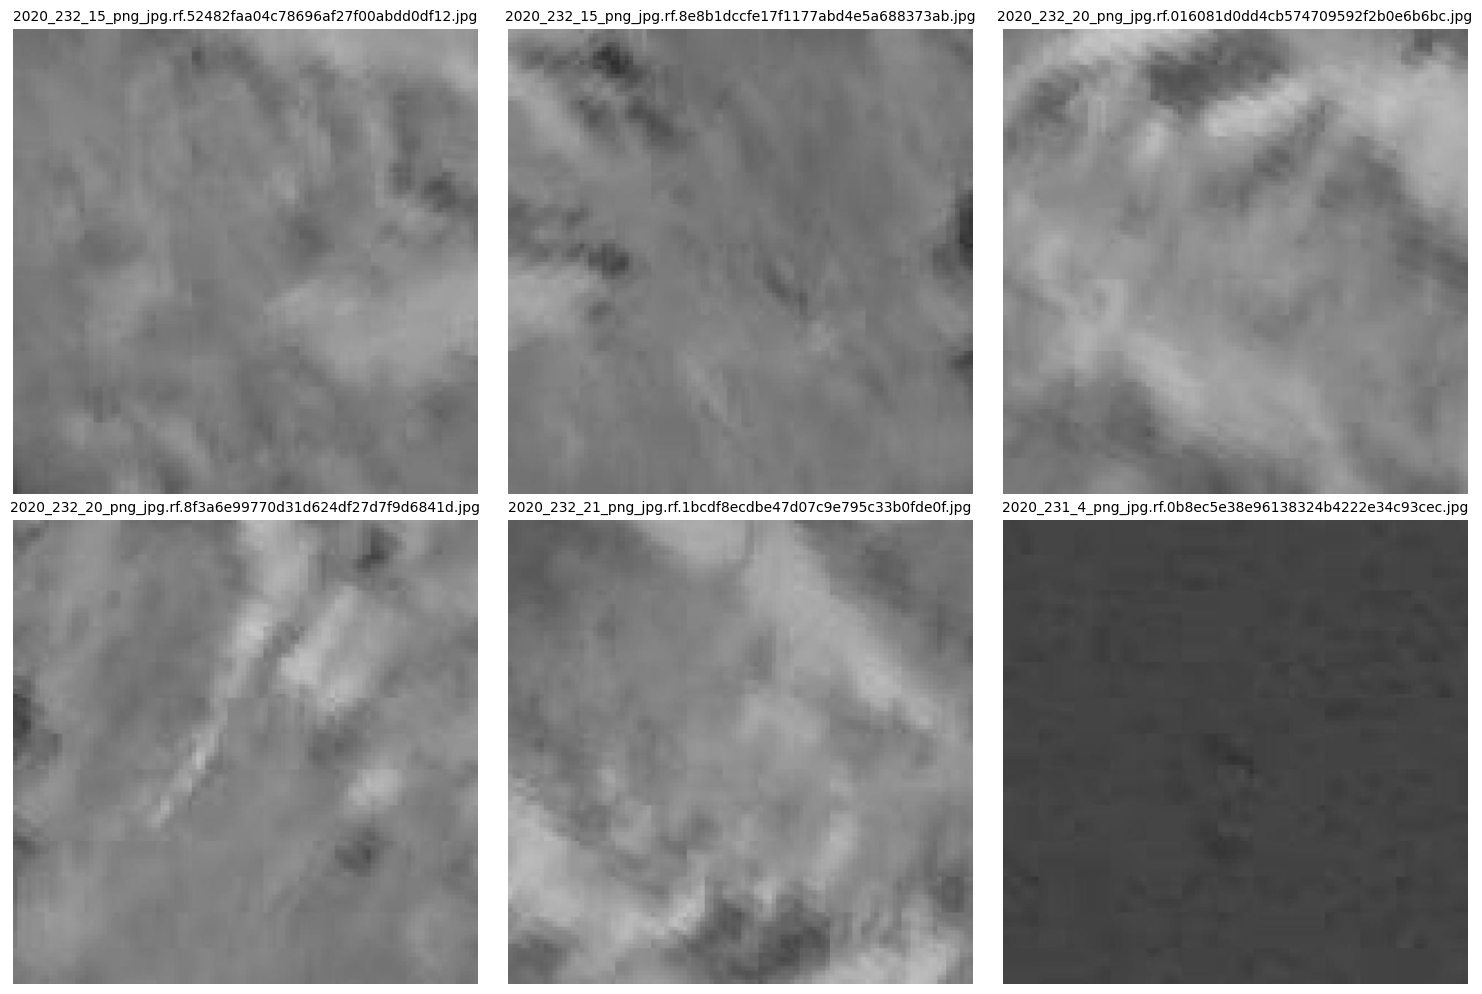


✅ Wyświetlono 6 obrazów z predykcjami


In [ ]:
# Wizualizacja wyników
if model is not None and model_type == "keras" and test_image_paths and 'results' in locals() and len(results) > 0:
    print("=" * 60)
    print("📊 WIZUALIZACJA WYNIKÓW")
    print("=" * 60)
    
    # Wybierz kilka obrazów do wizualizacji
    num_vis = min(6, len(results))
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i in range(num_vis):
        result = results[i]
        img_path = None
        for path in test_image_paths:
            if path.name == result['image']:
                img_path = path
                break
        
        if img_path and img_path.exists():
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].axis('off')
            
            # Dodaj informacje o predykcji
            if 'class' in result:
                title = f"{result['image']}\n{result['class']}"
                if 'confidence' in result:
                    title += f"\n({result['confidence']:.1%})"
                axes[i].set_title(title, fontsize=10)
            else:
                axes[i].set_title(result['image'], fontsize=10)
    
    # Ukryj nieużywane subploty
    for i in range(num_vis, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Wyświetlono {num_vis} obrazów z predykcjami")
else:
    print("⚠️  Nie można wyświetlić wizualizacji (brak wyników lub modelu)")

In [ ]:
# Podsumowanie wyników z YOLODataset
if model is not None and 'results' in locals() and results:
    print("=" * 60)
    print("📈 PODSUMOWANIE WYNIKÓW Z YOLODATASET")
    print("=" * 60)
    
    # Statystyki dla klasyfikacji
    if 'confidence' in results[0]:
        confidences = [r['confidence'] for r in results if 'confidence' in r]
        if confidences:
            print(f"\n📊 Statystyki pewności predykcji:")
            print(f"   Średnia: {np.mean(confidences):.2%}")
            print(f"   Mediana: {np.median(confidences):.2%}")
            print(f"   Min: {np.min(confidences):.2%}")
            print(f"   Max: {np.max(confidences):.2%}")
    
    # Rozkład klas (jeśli klasyfikacja wieloklasowa)
    if 'class' in results[0]:
        classes = [r['class'] for r in results]
        unique_classes, counts = np.unique(classes, return_counts=True)
        print(f"\n📋 Rozkład predykcji:")
        for cls, count in zip(unique_classes, counts):
            print(f"   {cls}: {count} ({count/len(results)*100:.1f}%)")
    
    print(f"\n✅ Przetestowano łącznie {len(results)} obrazów")
else:
    print("⚠️  Brak wyników do podsumowania")

📈 PODSUMOWANIE WYNIKÓW

✅ Przetestowano łącznie 10 obrazów
